<a href="https://colab.research.google.com/github/omershehzad70/Model-Training-Assignment/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction Using Machine Learning
**Course:** Artificial Intelligence
**Dataset:** WA_Fn-UseC_-Telco-Customer-Churn.csv

This notebook builds a complete machine learning pipeline to predict whether a telecom customer will churn (leave the company) based on their account and service information.


## 1. Data Loading and Understanding

We start by loading the dataset with Pandas and examining its structure: shape, column names, data types, and basic statistics. We also identify the target variable.


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn (1).csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())


Shape of dataset: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [20]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [21]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**What the columns represent:**

- **Customer demographics:** `gender`, `SeniorCitizen`, `Partner`, `Dependents` — basic information about the customer.
- **Account information:** `tenure` (number of months the customer has stayed), `Contract` (month-to-month, one year, two year), `PaperlessBilling`, `PaymentMethod`.
- **Subscribed services:** `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`.
- **Billing:** `MonthlyCharges` (amount billed monthly) and `TotalCharges` (total amount billed over the customer's tenure).
- **Target variable:** `Churn` — whether the customer left the company (`Yes`) or stayed (`No`). This is what our model will predict.


In [22]:
print(df['Churn'].value_counts())
print("\nChurn rate: {:.2f}%".format(df['Churn'].value_counts(normalize=True)['Yes']*100))


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.54%


The dataset has **7,043 customers** and is **imbalanced**: about 73% did not churn and 27% did. We will keep this in mind when evaluating our models, since accuracy alone can be misleading on imbalanced data — this is why we also look at Precision, Recall, and F1-score later.


## 2. Data Preprocessing

Before modeling, we check for missing values, duplicate rows, incorrect data types, and unnecessary columns.


In [23]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Pandas reports zero missing values, but that's misleading. `TotalCharges` is stored as *text* (object) instead of a number. Some rows contain a **blank string `" "`** instead of an actual number — these are "hidden" missing values that `isnull()` does not catch because they are technically non-null strings.


In [24]:
# Confirm the hidden issue in TotalCharges
blank_count = (df['TotalCharges'].str.strip() == '').sum()
print("Rows with blank TotalCharges:", blank_count)

# Convert to numeric; blanks become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing values after conversion:", df['TotalCharges'].isnull().sum())


Rows with blank TotalCharges: 11
Missing values after conversion: 11


In [25]:
# These 11 rows all have tenure == 0 (brand new customers, no bill yet).
# We fill them with the median TotalCharges rather than dropping them, to avoid losing data.
print(df[df['TotalCharges'].isnull()]['tenure'].describe())

df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())


count    11.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: tenure, dtype: float64


In [26]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


No duplicate rows were found, so no rows need to be removed for that reason.

Next, we drop `customerID`. It's a unique identifier for each row (like a name or ID card number) — it has no predictive relationship with churn and would only confuse the model or cause it to memorize individual customers rather than learn general patterns.


In [27]:
df.drop(columns=['customerID'], inplace=True)
print("Remaining columns:", df.shape[1])


Remaining columns: 20


**Summary of preprocessing decisions:**
1. Converted `TotalCharges` from text to numeric — required because it's fundamentally a numeric quantity and was stored incorrectly.
2. Filled the 11 resulting missing values with the median — these were brand-new customers (`tenure = 0`) who hadn't been billed yet, so imputing rather than deleting preserves data.
3. Confirmed no duplicate records exist.
4. Dropped `customerID` — a unique identifier with no predictive value.


## 3. Exploratory Data Analysis (EDA)

Now we explore patterns in the data — how churn relates to key customer characteristics.


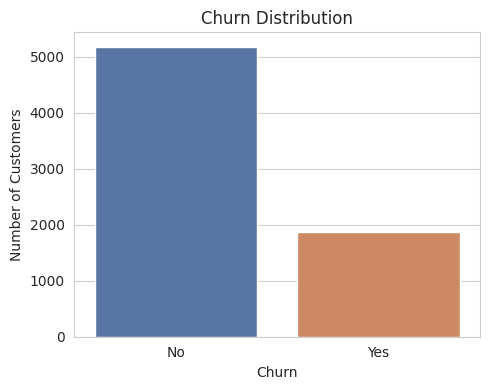

In [28]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Churn', hue='Churn', palette=['#4C72B0','#DD8452'], legend=False)
plt.title('Churn Distribution')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


**Observation:** The dataset is imbalanced — far more customers stayed than churned. This confirms we should not rely on accuracy alone when evaluating our models.


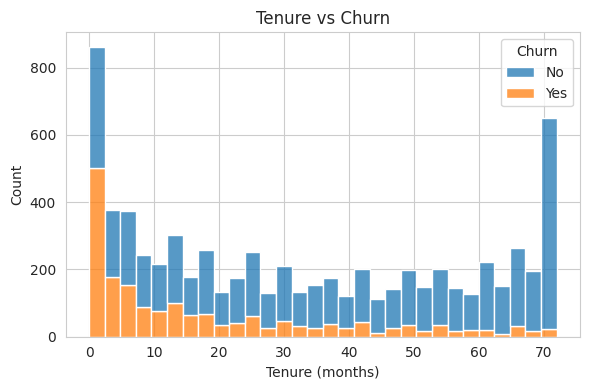

In [29]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, multiple='stack')
plt.title('Tenure vs Churn')
plt.xlabel('Tenure (months)')
plt.tight_layout()
plt.show()


**Observation:** Customers with **low tenure** (new customers) churn far more often than long-tenured customers. This suggests the first few months are critical for retention.


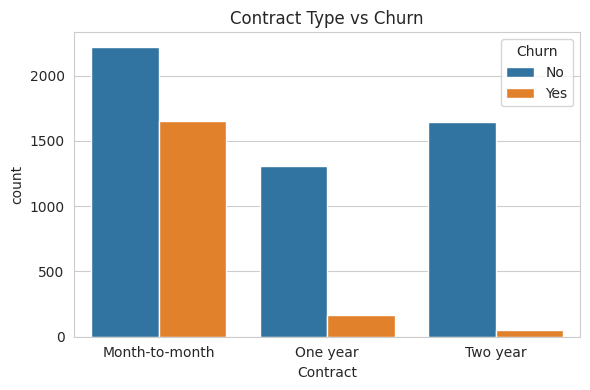

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Contract Type vs Churn')
plt.tight_layout()
plt.show()


**Observation:** Customers on **month-to-month contracts** churn at a much higher rate than those on one-year or two-year contracts. Longer commitments appear to strongly reduce churn.


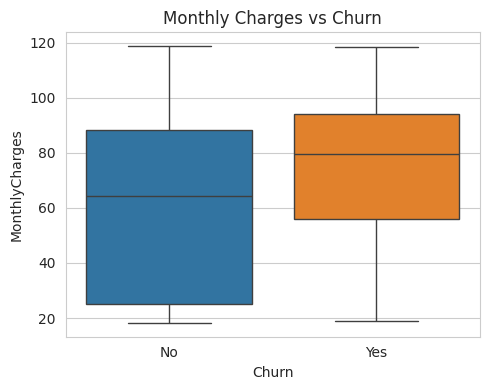

In [31]:
plt.figure(figsize=(5,4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', legend=False)
plt.title('Monthly Charges vs Churn')
plt.tight_layout()
plt.show()


**Observation:** Customers who churn tend to have **higher monthly charges** on average than those who stay, suggesting price sensitivity may play a role in churn decisions.


## 4. Feature Engineering and Encoding

Machine learning models require numeric input, so we convert all categorical (text) columns into numbers. We use:
- **Binary/label encoding** for Yes/No and two-category columns (e.g., `Partner`, `gender`).
- **One-hot encoding** (`pd.get_dummies`) for columns with more than two categories (e.g., `Contract`, `PaymentMethod`), so the model doesn't wrongly assume an order between categories.


In [32]:
df_model = df.copy()

# Binary columns: map Yes/No -> 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df_model[col] = df_model[col].map({'Yes': 1, 'No': 0})

df_model['gender'] = df_model['gender'].map({'Male': 1, 'Female': 0})
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})  # target variable

# Multi-category columns: one-hot encode
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                   'Contract', 'PaymentMethod']
df_model = pd.get_dummies(df_model, columns=multi_cat_cols, drop_first=True)

df_model.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [33]:
# Separate features (X) from target (y)
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (7043, 30)
y shape: (7043,)


`drop_first=True` avoids the "dummy variable trap" (redundant, perfectly correlated columns) by dropping one category per feature as the baseline.


## 5. Training and Testing

We split the data into training (80%) and testing (20%) sets, then train two classification models:
1. **Logistic Regression** — a simple, interpretable linear model, a good baseline for binary classification.
2. **Random Forest** — an ensemble of decision trees that can capture non-linear relationships and feature interactions.

We use `stratify=y` in the split to preserve the same churn ratio in both train and test sets, which matters because the classes are imbalanced.


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training set:", X_train.shape, " Testing set:", X_test.shape)


Training set: (5634, 30)  Testing set: (1409, 30)


Logistic Regression is sensitive to feature scale, so we standardize the features (mean 0, std 1) before training it. Random Forest is tree-based and does not require scaling, so we train it on the original values.


In [35]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1: Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Both models trained successfully.")


Both models trained successfully.


## 6. Model Evaluation

We evaluate both models using Accuracy, Precision, Recall, F1-Score, and the Confusion Matrix.

- **Accuracy:** overall proportion of correct predictions.
- **Precision:** of the customers predicted to churn, how many actually churned (relevant when the cost of a false alarm matters).
- **Recall:** of the customers who actually churned, how many did we correctly catch (relevant here, since missing a churner means losing a customer).
- **F1-Score:** the harmonic mean of precision and recall — a balanced summary metric, especially useful on imbalanced data.


In [36]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

def evaluate(name, y_true, y_pred):
    print(f"--- {name} ---")
    print("Accuracy: ", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall:   ", round(recall_score(y_true, y_pred), 4))
    print("F1-Score: ", round(f1_score(y_true, y_pred), 4))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print()

evaluate("Logistic Regression", y_test, y_pred_lr)
evaluate("Random Forest", y_test, y_pred_rf)


--- Logistic Regression ---
Accuracy:  0.807
Precision: 0.6584
Recall:    0.5668
F1-Score:  0.6092
Confusion Matrix:
[[925 110]
 [162 212]]

--- Random Forest ---
Accuracy:  0.8041
Precision: 0.6655
Recall:    0.5267
F1-Score:  0.5881
Confusion Matrix:
[[936  99]
 [177 197]]



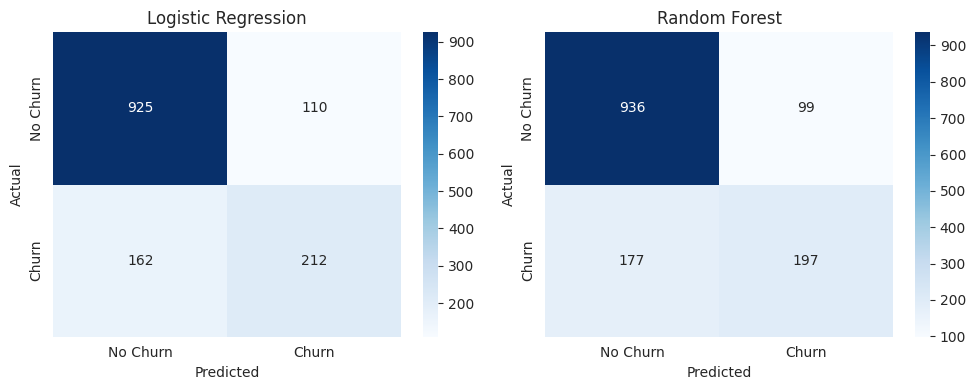

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
for ax, (name, yp) in zip(axes, [("Logistic Regression", y_pred_lr), ("Random Forest", y_pred_rf)]):
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


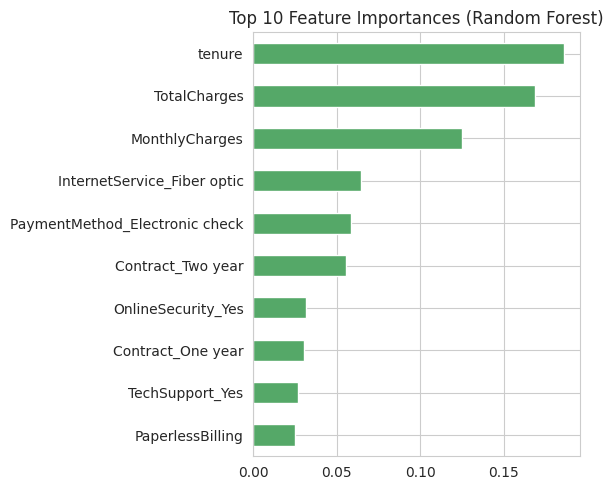

In [38]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(6,5))
importances.plot(kind='barh', color='#55A868')
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()


**Model comparison:** Both models perform similarly overall (roughly 80% accuracy), which is expected on this well-studied dataset. Logistic Regression achieves a slightly higher Recall, meaning it catches more of the customers who actually churn — which matters most for a retention use case, since failing to flag a churner is more costly to the business than a false alarm. Random Forest gives a useful bonus: feature importances, which show that **tenure, Contract type, and MonthlyCharges/TotalCharges** are the strongest predictors of churn, consistent with our EDA findings.

*(Exact numbers may shift slightly if you rerun this notebook, since Random Forest and the train/test split involve some randomness — but the overall pattern will hold.)*


## 7. Application / Prediction

Finally, we use the trained model to predict churn for a sample customer, showing how new customer data flows through the pipeline to produce a prediction.


In [39]:
# Take one customer from the test set as a sample
sample_customer = X_test.iloc[[0]]
actual_label = y_test.iloc[0]

# Predict with both models
sample_scaled = scaler.transform(sample_customer)
pred_lr = log_reg.predict(sample_scaled)[0]
pred_rf = rf.predict(sample_customer)[0]

print("Actual outcome:        ", "Churn" if actual_label == 1 else "No Churn")
print("Logistic Regression predicts:", "Churn" if pred_lr == 1 else "No Churn")
print("Random Forest predicts:      ", "Churn" if pred_rf == 1 else "No Churn")


Actual outcome:         No Churn
Logistic Regression predicts: No Churn
Random Forest predicts:       No Churn


In [40]:
# Predicted probability of churn (Random Forest), for more nuance than a hard Yes/No
prob = rf.predict_proba(sample_customer)[0][1]
print(f"Random Forest estimated churn probability: {prob*100:.1f}%")


Random Forest estimated churn probability: 0.9%


This shows the complete pipeline in action: raw customer information is preprocessed and encoded exactly like the training data, then fed into the trained model, which outputs both a class label (Churn / No Churn) and a probability score that a telecom company could use to prioritize retention efforts (e.g., contacting the highest-risk customers first).


## Conclusion

- Both Logistic Regression and Random Forest achieved solid, comparable performance (~80% accuracy) on this dataset, with Logistic Regression showing a slight edge in Recall — the more business-relevant metric here since the goal is to catch as many at-risk customers as possible.
- The most influential factors in predicting churn were **tenure**, **contract type**, and **monthly/total charges** — new customers on month-to-month contracts with higher bills are the most likely to leave.
- **Limitations:** the dataset is imbalanced (only ~27% churners), which can bias models toward the majority class; the models also don't account for external factors like competitor pricing or customer service interactions, which could improve real-world accuracy.
- **Business use:** a telecom company could deploy this model to score existing customers monthly, flag high-risk ones, and proactively offer retention incentives (discounts, contract upgrades) before they churn — turning a reactive support process into a proactive one.
